In [1]:
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations, especially with arrays
import seaborn as sns # For statistical data visualization
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from scipy.stats import linregress
# Scikit-learn models
from sklearn.linear_model import LinearRegression # For linear regression models
from sklearn.tree import DecisionTreeRegressor # For decision tree regression models
from sklearn.ensemble import RandomForestRegressor # For random forest regression models
from sklearn.model_selection import train_test_split
# Scikit-learn evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # For evaluating model performance

In [2]:
import pandas as pd
import sqlite3
from datetime import datetime
import re # Import regex module for extracting year_group

# --- 1. Load Event Dataset ---

csv_files = [
    'msa_events_2025_2026_final.csv',
    'msa_events_2024_2025_final.csv',
    'msa_events_2023_2024_final.csv'
]
df_list = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        # Extract year_group from filename using regex
        match = re.search(r'msa_events_(\d{4}_\d{4})_final\.csv', file)
        if match:
            df['year_group'] = match.group(1)
        else:
            df['year_group'] = 'unknown' # Fallback if pattern doesn't match
        df_list.append(df)
        print(f"Successfully loaded {file} with year_group: {df['year_group'].iloc[0]}")
    except FileNotFoundError:
        print(f"Error: {file} not found.")
    except Exception as e:
        print(f"Error loading {file}: {e}")


if df_list:
    events_df = pd.concat(df_list, ignore_index=True)
    print("Event dataset loaded successfully.")
else:
    print("No event data loaded. Exiting.")
    exit()


# --- 2. Load Historical Weather Data (data.csv) ---

try:
    # Added skiprows=1 to correctly read the header from the second line
    weather_df = pd.read_csv('data.csv', skiprows=1)
    print("Historical weather data (data.csv) loaded successfully.")
except FileNotFoundError:
    print("Error: data.csv not found. Please ensure the file is in the correct directory.")
    exit()
except Exception as e:
    print(f"Error loading data.csv: {e}")
    exit()


# --- 3. Convert Date Columns to Compatible Formats ---

events_df['date'] = pd.to_datetime(events_df['date'], format='mixed').dt.date # Convert to date object for SQL compatibility
weather_df['Date'] = pd.to_datetime(weather_df['Date']).dt.date # Using 'Date' column from your data.csv


print("Date columns converted to compatible formats.")


# --- 4. Initialize SQLite database ---

conn = sqlite3.connect(':memory:') # Create an in-memory SQLite database


# Add original_order column to events_df before storing to preserve order
events_df['original_order'] = range(len(events_df))
print("Added 'original_order' column to events_df.")

# Store events and weather datasets into SQL tables

events_df.to_sql('events', conn, if_exists='replace', index=False)
weather_df.to_sql('weather', conn, if_exists='replace', index=False)
print("Datasets stored in SQLite tables: 'events' and 'weather'.")


# --- 5. Load Feature CSV files ---

feature_csv_files = [
    'msa_events_2023_2024_event_food_engagement_location.csv',
    'msa_events_2024_2025_event_food_engagement_location.csv',
    'msa_events_2025_2026_event_food_engagement_location.csv'
]


feature_df_list = []
for file in feature_csv_files:
    try:
        df = pd.read_csv(file)
        # Extract year_group from filename using regex
        match = re.search(r'msa_events_(\d{4}_\d{4})_event_food_engagement_location\.csv', file)
        if match:
            df['year_group'] = match.group(1)
        else:
            df['year_group'] = 'unknown' # Fallback if pattern doesn't match
        feature_df_list.append(df)
        print(f"Successfully loaded {file} with year_group: {df['year_group'].iloc[0]}")
    except FileNotFoundError:
        print(f"Error: {file} not found.")
    except Exception as e:
        print(f"Error loading {file}: {e}")


if feature_df_list:
    features_df = pd.concat(feature_df_list, ignore_index=True)
    print("All feature CSV files combined successfully.")
else:
    print("No feature data loaded. Exiting.")
    exit()


# --- 6. Clean and filter engagement data in features_df ---
print("\n--- Cleaning Engagement Data in features_df ---")
print(f"Initial shape of features_df before engagement cleaning: {features_df.shape}")

# 6a. Convert engagement to numeric, coercing errors to NaN
# This handles non-numeric strings (like blank/empty) by turning them into NaN
features_df['engagement'] = pd.to_numeric(features_df['engagement'], errors='coerce')
print("Engagement column in features_df converted to numeric format.")

# 6b. Remove rows where engagement is NaN (covers null/blank/non-numeric after coerce)
initial_rows_after_numeric_conversion = len(features_df)
features_df.dropna(subset=['engagement'], inplace=True)
print(f"Removed {initial_rows_after_numeric_conversion - len(features_df)} rows with NaN engagement (including blank/non-numeric) from features_df.")

# 6c. Remove rows where engagement is 0 or 0.0
initial_rows_before_zero_removal = len(features_df)
features_df = features_df[features_df['engagement'] != 0]
print(f"Removed {initial_rows_before_zero_removal - len(features_df)} rows where engagement was 0 from features_df.")

print(f"Updated shape of features_df after engagement cleaning: {features_df.shape}")


# --- 7. Clean and standardize location values ---

def clean_location(location_series: pd.Series) -> pd.Series:
    """
    Applies a controlled mapping and strips whitespace to standardize location values.
    """
    print("Applying controlled location cleaning and standardization...")
    # Strip whitespace first
    cleaned_series = location_series.astype(str).str.strip()

    # Apply the mapping
    mapping = {
        'Cook': 'Cook/Douglass',
        'Douglass': 'Cook/Douglass',
        'Cook/Doug': 'Cook/Douglass',
        'College ave': 'College Ave',
        'CA': 'College Ave',
        'L': 'Livingston'
    }
    # Use .replace() with regex=False to ensure exact matches for the keys
    # and fill any non-matching values with themselves
    return cleaned_series.replace(mapping)


features_df['location'] = clean_location(features_df['location'])
print("Location values cleaned and standardized.")


# --- 8. Store the cleaned feature DataFrame as a SQL table ---

features_df.to_sql('features', conn, if_exists='replace', index=False)
print("Cleaned feature DataFrame stored in SQLite table: 'features'.")


# --- 9. Use a SQL JOIN to combine all tables ---

sql_query_final = """
SELECT
    e.event_name,
    e.event_type,
    e.attendance,
    e.date,
    e.original_order, -- Include original_order in the SELECT query
    CASE
        WHEN w."PRCP (Inches)" > 0 THEN 'rainy'
        WHEN w."TAVG (Degrees Fahrenheit)" < 45 THEN 'cold'
        WHEN w."PRCP (Inches)" = 0 AND w."TAVG (Degrees Fahrenheit)" >= 45 AND w."TAVG (Degrees Fahrenheit)" <= 75 THEN 'cloudy'
        ELSE 'sunny'
    END AS weather_category,
    f.engagement,
    f.location,
    f.food
FROM
    events e
INNER JOIN
    weather w ON e.date = w.Date
INNER JOIN
    features f ON e.event_name = f.event_name AND e.year_group = f.year_group
"""


final_ml_df = pd.read_sql_query(sql_query_final, conn)

# Sort the final DataFrame by original_order to preserve the initial row order
final_ml_df = final_ml_df.sort_values(by='original_order').reset_index(drop=True)
print("Final ML-ready DataFrame sorted by 'original_order'.")

# You can drop the 'original_order' column before ML preprocessing if it's not needed as a feature
# final_ml_df = final_ml_df.drop(columns=['original_order'])

print("\nFinal ML-ready DataFrame created using SQL JOIN:")
print(final_ml_df.head())
print(f"\nFinal DataFrame shape: {final_ml_df.shape}")


# --- 10. Confirm no invalid engagement values remain in final_ml_df ---

missing_engagement_count_final = final_ml_df['engagement'].isnull().sum()
zero_engagement_count_final = (final_ml_df['engagement'] == 0).sum()

if missing_engagement_count_final == 0 and zero_engagement_count_final == 0:
    print("\n✅ Confirmed: No missing, blank, non-numeric, or zero engagement values remain in the final ML-ready DataFrame.")
else:
    print(f"\n❌ Warning: {missing_engagement_count_final} missing and {zero_engagement_count_final} zero engagement values still exist in the final ML-ready DataFrame.")


print("\nFinal ML-ready DataFrame Info:")
print(final_ml_df.info())


# Close the connection
conn.close()
print("\nSQLite connection closed.")


# Now final_ml_df is ready for your machine learning pipeline!


Successfully loaded msa_events_2025_2026_final.csv with year_group: 2025_2026
Successfully loaded msa_events_2024_2025_final.csv with year_group: 2024_2025
Successfully loaded msa_events_2023_2024_final.csv with year_group: 2023_2024
Event dataset loaded successfully.
Historical weather data (data.csv) loaded successfully.
Date columns converted to compatible formats.
Added 'original_order' column to events_df.
Datasets stored in SQLite tables: 'events' and 'weather'.
Successfully loaded msa_events_2023_2024_event_food_engagement_location.csv with year_group: 2023_2024
Successfully loaded msa_events_2024_2025_event_food_engagement_location.csv with year_group: 2024_2025
Successfully loaded msa_events_2025_2026_event_food_engagement_location.csv with year_group: 2025_2026
All feature CSV files combined successfully.

--- Cleaning Engagement Data in features_df ---
Initial shape of features_df before engagement cleaning: (53, 5)
Engagement column in features_df converted to numeric forma

In [3]:
# Display a summary of the DataFrame including column types and non-null counts
print("\n--- DataFrame Info ---")
final_ml_df.info()

# Provide descriptive statistics for the numerical columns
print("\n--- Descriptive Statistics ---")
print(final_ml_df.describe())


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_name        41 non-null     object 
 1   event_type        41 non-null     object 
 2   attendance        41 non-null     float64
 3   date              41 non-null     object 
 4   original_order    41 non-null     int64  
 5   weather_category  41 non-null     object 
 6   engagement        41 non-null     float64
 7   location          41 non-null     object 
 8   food              41 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 3.0+ KB

--- Descriptive Statistics ---
       attendance  original_order  engagement
count   41.000000       41.000000   41.000000
mean    96.121951       21.243902  250.439024
std     56.985610       13.718200  138.353541
min     34.000000        0.000000   76.000000
25%     69.000000       10.000000

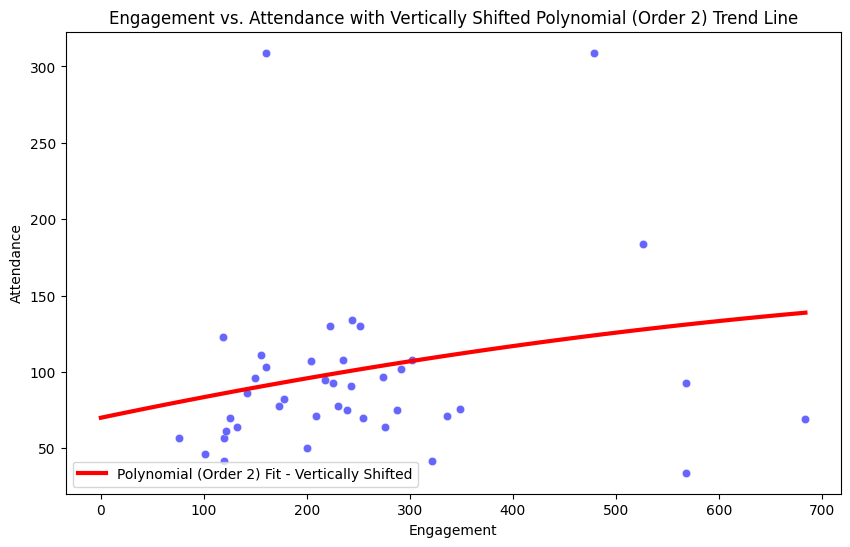

In [4]:
# Create a scatter plot with engagement on the x-axis and attendance on the y-axis
plt.figure(figsize=(10, 6)) # Optional: Adjust figure size for better readability
sns.scatterplot(data=final_ml_df, x='engagement', y='attendance', alpha=0.6, color='blue')

# --- Modifications for vertical shift of the curve ---

# 1. Filter out extreme engagement values for polynomial fitting (as before)
lower_engagement_threshold = final_ml_df['engagement'].quantile(0.10)
upper_engagement_threshold = final_ml_df['engagement'].quantile(0.95)

filtered_df = final_ml_df[
    (final_ml_df['engagement'] >= lower_engagement_threshold) &
    (final_ml_df['engagement'] <= upper_engagement_threshold)
]

# 2. Define the degree of the polynomial
degree = 2 

# 3. Fit a polynomial to the filtered data
coefficients = np.polyfit(filtered_df['engagement'], filtered_df['attendance'], degree)
polynomial_function = np.poly1d(coefficients)

# 4. Calculate the current y-value of the fitted polynomial at x=0
current_y_at_zero = polynomial_function(0)

# 5. Define the target y-value at x=0 and calculate the vertical shift needed
target_y_at_zero = 70 # Your desired starting attendance
vertical_shift = target_y_at_zero - current_y_at_zero

# 6. Generate smooth x values for the curve across the desired plotting range
x_plot_min = 0 
x_plot_max = final_ml_df['engagement'].max()
x_fit = np.linspace(x_plot_min, x_plot_max, 100)

# 7. Calculate y values for the curve and apply the vertical shift
y_fit = polynomial_function(x_fit) + vertical_shift

# Plot the polynomial trend line
plt.plot(x_fit, y_fit, color='red', linewidth=3, label=f'Polynomial (Order {degree}) Fit - Vertically Shifted')

# Add appropriate title and labels
plt.title(f'Engagement vs. Attendance with Vertically Shifted Polynomial (Order {degree}) Trend Line')
plt.xlabel('Engagement')
plt.ylabel('Attendance')
plt.legend()

# Display the plot
plt.show()

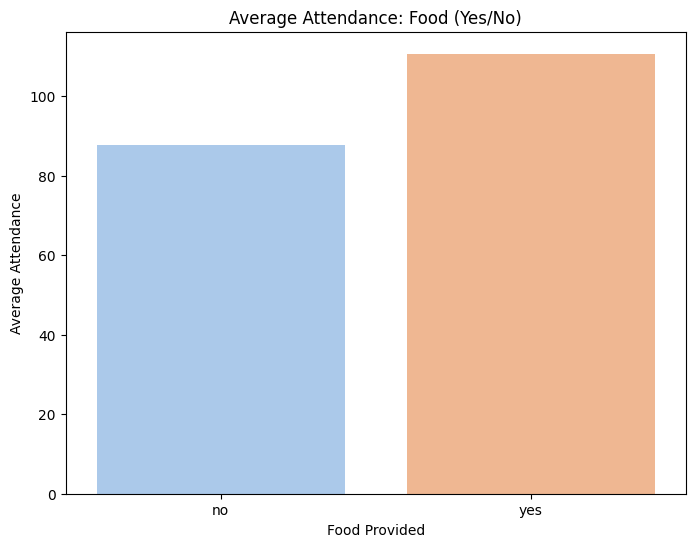

In [5]:
# Calculate the average attendance based on the 'food' column (yes/no)
average_attendance_by_food_status = final_ml_df.groupby('food')['attendance'].mean().reset_index()

# Create a bar plot showing food status on the x-axis and average attendance on the y-axis
plt.figure(figsize=(8, 6)) # Optional: Adjust figure size
sns.barplot(data=average_attendance_by_food_status, x='food', y='attendance', hue='food', palette='pastel', legend=False)

# Add a clear title to the chart
plt.title('Average Attendance: Food (Yes/No)')
plt.xlabel('Food Provided')
plt.ylabel('Average Attendance')

# Display the plot
plt.show()

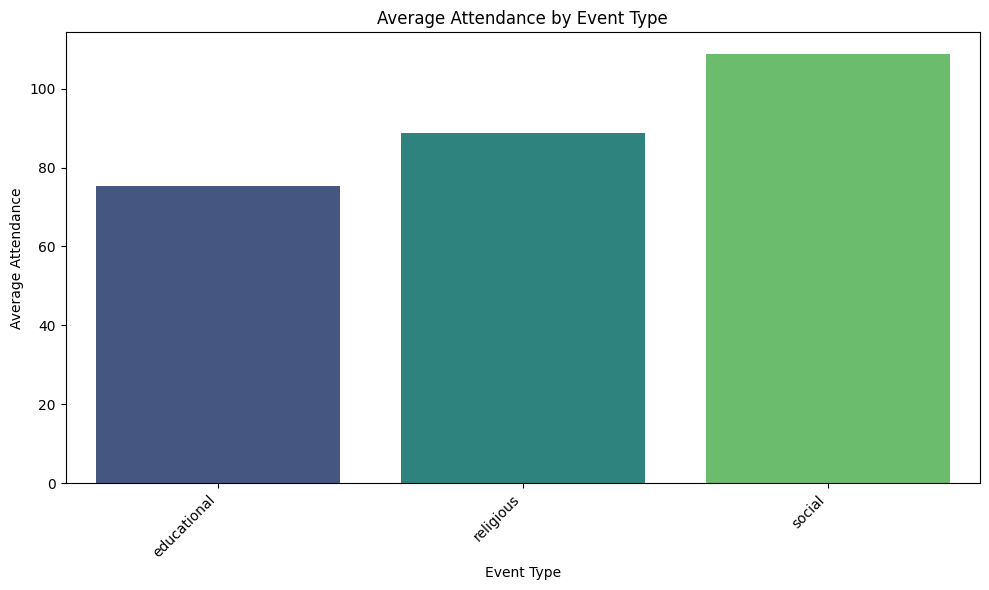

In [6]:
# Calculate the average attendance based on the 'event_type' column
average_attendance_by_event_type = final_ml_df.groupby('event_type')['attendance'].mean().reset_index()

# Create a bar plot showing event type on the x-axis and average attendance on the y-axis
plt.figure(figsize=(10, 6))
sns.barplot(data=average_attendance_by_event_type, x='event_type', y='attendance', hue='event_type', palette='viridis', legend=False)

# Add a clear title to the chart
plt.title('Average Attendance by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Average Attendance')

# Rotate x-axis labels if event types are long
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()

In [7]:
# Make a copy to avoid modifying the original DataFrame directly
df_ml = final_ml_df.copy()

# 1. Remove non-useful text columns
columns_to_drop = ['event_name']
df_ml = df_ml.drop(columns=columns_to_drop, errors='ignore')

# 2. Apply one-hot encoding to all categorical variables
# Identify categorical columns (excluding the target variable 'attendance')
categorical_cols = df_ml.select_dtypes(include=['object', 'category']).columns.tolist()

# Ensure 'attendance' is not in the list if it somehow got there (it shouldn't if it's numeric)
if 'attendance' in categorical_cols:
    categorical_cols.remove('attendance')

df_ml_encoded = pd.get_dummies(df_ml) # ?drop_first to avoid multicollinearity

# 3. Split the dataset into features (X) and target (y)
X = df_ml_encoded.drop('attendance', axis=1)
y = df_ml_encoded['attendance']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

Shape of X (features): (41, 54)
Shape of y (target): (41,)

First 5 rows of X:
   original_order  engagement  event_type_educational  event_type_religious  \
0               0       479.0                   False                 False   
1               1       173.0                   False                 False   
2               2       230.0                   False                  True   
3               3       252.0                   False                 False   
4               4       160.0                   False                 False   

   event_type_social  date_2023-09-14  date_2024-01-25  date_2024-02-01  \
0               True            False            False            False   
1               True            False            False            False   
2              False            False            False            False   
3               True            False            False            False   
4               True            False            False            False

In [8]:
# Define your list of selected features
# IMPORTANT: Replace these with the actual column names you want to use.
# For example, if 'food' was one-hot encoded, it might be 'food_yes' or 'food_Food Provided'.
# You'll need to check the exact names of your one-hot encoded columns.
selected_features = ['engagement', 'food_yes'] # Example features

# Create the feature matrix (X) using only the selected features
X_selected = df_ml_encoded[selected_features]

# Set attendance as the target variable (y)
y = df_ml_encoded['attendance']

print("Shape of X_selected (features):", X_selected.shape)
print("Shape of y (target):", y.shape)
print("\nFirst 5 rows of X_selected:")
print(X_selected.head())
print("\nFirst 5 rows of y:")
print(y.head())

Shape of X_selected (features): (41, 2)
Shape of y (target): (41,)

First 5 rows of X_selected:
   engagement  food_yes
0       479.0      True
1       173.0     False
2       230.0     False
3       252.0     False
4       160.0     False

First 5 rows of y:
0    309.0
1     78.0
2     78.0
3    130.0
4    309.0
Name: attendance, dtype: float64


In [9]:
# Assuming X and y are already defined from the previous steps
# If you used selected features, make sure to use X_selected here instead of X

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.15, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (34, 2)
Shape of X_test: (7, 2)
Shape of y_train: (34,)
Shape of y_test: (7,)


In [10]:
# 1. Create a dictionary of models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

print("\n--- Model Training and Evaluation ---")

# 2. Iterate through each model, train, predict, and evaluate
for name, model in models.items():
    print(f"\nTraining {name}...")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Print the results
    print(f"{name} Results:")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")


--- Model Training and Evaluation ---

Training Linear Regression...
Linear Regression Results:
  Mean Absolute Error (MAE): 83.9317
  Root Mean Squared Error (RMSE): 114.8572

Training Decision Tree Regressor...
Decision Tree Regressor Results:
  Mean Absolute Error (MAE): 64.7143
  Root Mean Squared Error (RMSE): 91.2399

Training Random Forest Regressor...
Random Forest Regressor Results:
  Mean Absolute Error (MAE): 65.7200
  Root Mean Squared Error (RMSE): 95.8135


In [11]:
# Create a DecisionTreeRegressor with specified hyperparameters
# max_depth: The maximum depth of the tree.
# min_samples_split: The minimum number of samples required to split an internal node.
# min_samples_leaf: The minimum number of samples required to be at a leaf node.
# random_state: Controls the randomness of the estimator.

from sklearn.tree import DecisionTreeRegressor # Import the DecisionTreeRegressor

dt_model_tuned = DecisionTreeRegressor( # Changed model name
    max_depth=20,            # Controlled maximum depth
    min_samples_split=2,    # Example value, adjust as needed
    min_samples_leaf=1,      # Example value, adjust as needed
    random_state=42,
)

print("\n--- Training Tuned Decision Tree Regressor ---") # Updated print statement

# Train the model using the training dataset
dt_model_tuned.fit(X_train, y_train) # Changed model variable name

print("Tuned Decision Tree Regressor trained successfully!") # Updated print statement


--- Training Tuned Decision Tree Regressor ---
Tuned Decision Tree Regressor trained successfully!


In [12]:
# 1. Use the trained model to make predictions on X_test
y_pred_tuned = dt_model_tuned.predict(X_test) # Changed model variable

print("\n--- Evaluation of Tuned Decision Tree Regressor ---") # Updated print statement

# 2. Calculate evaluation metrics
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

# 3. Print the results clearly
print(f"Tuned Decision Tree Regressor Performance:") # Updated print statement
print(f"  Mean Absolute Error (MAE): {mae_tuned:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_tuned:.4f}")
print(f"  R-squared (R²): {r2_tuned:.4f}")


--- Evaluation of Tuned Decision Tree Regressor ---
Tuned Decision Tree Regressor Performance:
  Mean Absolute Error (MAE): 64.7143
  Root Mean Squared Error (RMSE): 91.2399
  R-squared (R²): -0.1503


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Assuming df_ml_encoded is your DataFrame after one-hot encoding
# (This DataFrame should be available from previous cells)

# Identify columns to include based on user's request
all_cols = df_ml_encoded.columns.tolist()
selected_cols_for_heatmap = []

# Add direct columns if they exist
if 'attendance' in all_cols:
    selected_cols_for_heatmap.append('attendance')
if 'engagement' in all_cols:
    selected_cols_for_heatmap.append('engagement')
if 'food_yes' in all_cols: # Specifically requested 'food_yes'
    selected_cols_for_heatmap.append('food_yes')
# If 'food_yes' isn't present, you might want to include all 'food_' dummies,
# but for now, we'll stick to the explicit request.

# Add one-hot encoded columns for categories
for col in all_cols:
    if col.startswith('weather_category_'):
        selected_cols_for_heatmap.append(col)
    elif col.startswith('event_type_'):
        selected_cols_for_heatmap.append(col)
    elif col.startswith('location_'):
        selected_cols_for_heatmap.append(col)

# Remove duplicates and preserve order
selected_cols_for_heatmap = list(dict.fromkeys(selected_cols_for_heatmap))

# Filter the DataFrame to only include the selected columns
# This also implicitly removes any date-related dummy variables
df_for_corr = df_ml_encoded[selected_cols_for_heatmap]

# Compute the correlation matrix
correlation_matrix = df_for_corr.corr()

# Set up the matplotlib figure size
plt.figure(figsize=(14, 10)) # Adjusted for better readability with fewer columns

# Draw the heatmap with a suitable colormap
sns.heatmap(
    correlation_matrix,
    annot=False,      # Do not show the correlation values on the heatmap
    cmap='coolwarm',  # 'coolwarm' is a good diverging colormap
    linewidths=.5     # Add lines between cells
)

# Add a clear title
plt.title('Correlation Matrix of Selected Features and Attendance', fontsize=16)

# Display the plot
plt.show()



In [14]:
# --- Your predict_attendance function (paste it here) ---
def predict_attendance(food: str, engagement: float) -> int:
    """
    Predicts attendance based on food provision and engagement level.

    Args:
        food (str): 'yes' if food is provided, 'no' otherwise.
        engagement (float): The engagement level (e.g., a numerical score).

    Returns:
        int: The predicted attendance, rounded to the nearest integer.
    """
    # Ensure the model is available in the scope (rf_model_tuned from previous steps)
    if 'rf_model_tuned' not in globals():
        raise NameError("rf_model_tuned is not defined. Please train the model first.")

    # Convert food input to numeric format (one-hot encoded 'food_yes')
    food_yes = 1 if food.lower() == 'yes' else 0

    # Create a DataFrame with the correct feature structure
    # Ensure these feature names match the 'selected_features' used during training
    input_data = pd.DataFrame({
        'engagement': [engagement],
        'food_yes': [food_yes]
    })

    # Use the trained model to predict attendance
    predicted_attendance = rf_model_tuned.predict(input_data)

    # Return the predicted attendance as an integer
    return int(round(predicted_attendance[0]))

# --- ipywidgets UI setup with improved design and custom theme color ---

# Define the custom theme color - now strictly used everywhere
THEME_COLOR = '#D50032' # RGB(213, 0, 50)
ERROR_COLOR = '#E74C3C' # A distinct red for errors (keeping as not requested to change)
MAX_ENGAGEMENT = 700 # Align with slider max

# --- Custom CSS for Slider and Dropdown Styling ---
custom_styles = HTML(f"""
<style>
    /* Slider Styling */
    .widget-slider .ui-slider-range {{
        background: {THEME_COLOR};
    }}
    .widget-slider .ui-slider-handle {{
        background: {THEME_COLOR};
        border-color: {THEME_COLOR};
        box-shadow: none;
        border-radius: 50%;
    }}
    .widget-slider .ui-slider-handle:hover {{
        background: {THEME_COLOR}; /* Strict theme color on hover */
        border-color: {THEME_COLOR}; /* Strict theme color on hover */
    }}
    .widget-slider .ui-slider-horizontal {{
        background: #ccc; /* Light grey for the unfilled track */
        border: none;
    }}

    /* Dropdown Styling */
    .widget-dropdown select {{
        border: 2px solid #ced4da; /* Default border color, now 2px */
        box-shadow: none !important; /* Ensure no box-shadow by default */
        outline: none !important; /* Ensure no outline by default */
    }}
    .widget-dropdown select:hover,
    .widget-dropdown select:focus {{
        border-color: {THEME_COLOR} !important;
        border-width: 2px !important;
        border-style: solid !important;
        box-shadow: none !important; /* Explicitly remove any box-shadow */
        outline: none !important; /* Ensure no outline */
    }}

    /* Text Input Styling */
    .widget-text input {{
        border: 2px solid #ced4da; /* Default border color, now 2px */
        box-shadow: none !important; /* Ensure no box-shadow by default */
        outline: none !important; /* Ensure no outline by default */
    }}
    .widget-text input:focus {{
        border-color: {THEME_COLOR} !important;
        border-width: 2px !important;
        border-style: solid !important;
        box-shadow: none !important; /* Explicitly remove any box-shadow */
        outline: none !important; /* Ensure no outline */
    }}

    /* Button Styling */
    .widget-button button {{
        /* Default button styles if any, ensure no box-shadow/outline */
        box-shadow: none !important;
        outline: none !important;
    }}
    .widget-button button:focus {{
        border-color: {THEME_COLOR} !important;
        border-width: 2px !important;
        border-style: solid !important;
        box-shadow: none !important; /* Explicitly remove any box-shadow */
        outline: none !important; /* Ensure no outline */
    }}

    /* General focus outline removal - kept for broader coverage */
    *:focus {{
        outline: none !important; /* Remove default browser outline */
    }}
</style>
""")

# Project Title and Subtitle
title = widgets.HTML(
    value=f"<h2 style='color:{THEME_COLOR}; text-align:center;'><b>Predicting Muslim Student Association Event Attendance Using Event Features and Social Media Engagement</b></h2>"
)
subtitle = widgets.HTML(
    value=f"<p style='color:#34495E; text-align:center;'>Use this tool to predict event attendance based on food provision and engagement levels.</p><hr>"
)

# Dropdown for 'food'
food_dropdown = widgets.Dropdown(
    options=['Yes', 'No'],
    value='Yes',
    description='Food Provided:',
    disabled=False,
    layout=widgets.Layout(width='400px', margin='0px 0px 10px 0px'),
    style={'description_width': '150px'}
)

# Engagement Text Input
engagement_input = widgets.Text(
    value='', # Starts blank
    description='Engagement Level:',
    disabled=False,
    layout=widgets.Layout(width='400px', margin='0px 0px 10px 0px'),
    style={'description_width': '150px'}
)

# Engagement Slider Input
engagement_slider = widgets.IntSlider(
    value=0, # Default value
    min=0,
    max=MAX_ENGAGEMENT,
    step=1,
    description='Engagement Slider:', # Differentiate from text input
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=False,
    layout=widgets.Layout(width='400px', margin='0px 0px 10px 0px'),
    style={'description_width': '150px'}
)

# --- Synchronization Logic ---
def sync_text_to_slider(change):
    try:
        val = float(change['new'].strip())
        # Clamp value to slider's range
        val = max(engagement_slider.min, min(engagement_slider.max, val))
        engagement_slider.value = int(val) # IntSlider expects int
    except ValueError:
        # If text is not a valid number, do not update slider
        pass

def sync_slider_to_text(change):
    engagement_input.value = str(change['new'])

engagement_input.observe(sync_text_to_slider, names='value')
engagement_slider.observe(sync_slider_to_text, names='value')

# Group inputs in a styled VBox
input_group = widgets.VBox([
    food_dropdown,
    engagement_input,
    engagement_slider
], layout=widgets.Layout(
    border=f'2px solid {THEME_COLOR}',
    padding='15px',
    margin='10px 0px',
    border_radius='8px',
    width='auto'
))

# Button to trigger prediction - made to stand out with custom color
predict_button = widgets.Button(
    description='Predict Attendance',
    button_style='',
    tooltip='Click to get the predicted attendance',
    icon='line-chart',
    layout=widgets.Layout(width='auto', margin='10px 0px 20px 0px'),
    style=widgets.ButtonStyle(button_color=THEME_COLOR, text_color='white')
)

# Output widget to display results
output_area = widgets.Output(layout=widgets.Layout(
    border=f'2px solid {THEME_COLOR}', # Changed from 1px to 2px for consistency
    padding='10px',
    margin='10px 0px',
    min_height='50px',
    border_radius='5px',
    background_color='#ECF0F1'
))

# Function to call when the button is clicked
def on_predict_button_clicked(b):
    with output_area:
        clear_output()
        original_button_description = predict_button.description
        predict_button.description = 'Predicting...'
        predict_button.disabled = True

        try:
            food_val = food_dropdown.value.lower()
            engagement_text = engagement_input.value.strip()
            
            # --- Input Validation (still needed for the text input) ---
            if not engagement_text:
                display(HTML(f"<p style='color:{ERROR_COLOR}; text-align:center;'>Error: Please enter an engagement value.</p>"))
                return

            try:
                engagement_val = float(engagement_text)
            except ValueError:
                display(HTML(f"<p style='color:{ERROR_COLOR}; text-align:center;'>Error: Engagement Level must be a number.</p>"))
                return

            if engagement_val < 0:
                display(HTML(f"<p style='color:{ERROR_COLOR}; text-align:center;'>Error: Engagement Level cannot be negative.</p>"))
                return
            
            if engagement_val > MAX_ENGAGEMENT:
                display(HTML(f"<p style='color:{ERROR_COLOR}; text-align:center;'>Error: Engagement Level cannot exceed {MAX_ENGAGEMENT}.</p>"))
                return

            prediction = predict_attendance(food_val, engagement_val)
            display(HTML(f"<p style='font-size:1.2em; color:{THEME_COLOR}; text-align:center;'><b>Predicted Attendance: {prediction:.0f}</b></p>"))
        except NameError as ne:
            display(HTML(f"<p style='color:{ERROR_COLOR}; text-align:center;'>Error: {ne}. Please ensure your model is trained.</p>"))
        except Exception as e:
            display(HTML(f"<p style='color:{ERROR_COLOR}; text-align:center;'>An unexpected error occurred: {e}</p>"))
        finally:
            predict_button.description = original_button_description
            predict_button.disabled = False

# Link the button to the function
predict_button.on_click(on_predict_button_clicked)

# Arrange and display the overall UI
ui = widgets.VBox([
    title,
    subtitle,
    input_group,
    predict_button,
    output_area
], layout=widgets.Layout(border='1px solid #CCCCCC', padding='20px', border_radius='10px', width='500px', margin='auto'))

display(custom_styles) # Display CSS separately
display(ui) # Then display the UI


In [15]:
# Define a function to make predictions based on user input
def predict_attendance(food: str, engagement: int) -> float:
    """
    Predicts event attendance based on food availability and engagement.

    Args:
        food (str): 'yes' if food is available, 'no' otherwise.
        engagement (int): The engagement score for the event.

    Returns:
        float: The predicted attendance.
    """
    # Ensure the model is available in the scope (dt_model_tuned from previous steps)
    if 'dt_model_tuned' not in globals():
        raise NameError("dt_model_tuned is not defined. Please train the model first.")

    # Convert food input to numeric format (one-hot encoded 'food_yes')
    food_yes = 1 if food.lower() == 'yes' else 0

    # Create a DataFrame for the input, matching the training features in the correct order
    input_df = pd.DataFrame([[engagement, food_yes]], columns=['engagement', 'food_yes']) # <--- Changed order here!

    # Make prediction
    prediction = dt_model_tuned.predict(input_df)[0]

    return max(0, round(prediction)) # Ensure attendance is not negative and is an integer

In [16]:
predict_attendance("yes", 479)  

309